# Librerias


In [1]:
# importing packages
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import json

In [2]:
pip install seaborn

In [3]:
pip install vapeplot

# Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys
sys.path.append('/content/drive/MyDrive/Results_Analysis/Notebooks')

In [6]:
from chargers import *
from metrics import *
from graphs import *

In [7]:
notebooks_route = "/content/drive/My Drive/Results_Analysis/Notebooks/"

In [8]:
experiment = "abortion" # presidential, plebiscite, or abortion
column_to_predict = 'religion_14'

In [9]:
results_route =  f"/content/drive/My Drive/Results_Analysis/results_dataframes/{experiment}/"
prompt_design_route =  f"/content/drive/My Drive/Results_Analysis/results_dataframes/{experiment}/Prompt Design Variations/"

# Dataframes Upload

In [10]:
d = {
  "abortodebeserpermitidosoloencasosespeciales":2,
  "abortion should be prohibited in all cases":1,
  "always prohibited":1,
  "abortion should be allowed in cases of special circumstances":2,
  "always be prohibited":1,
  "aborto debe estar permitido en cualquier caso": 3,
  "permitir el aborto en cualquier caso":3,
  "abortion should be permitted in any case":3,
  "abortion should be allowed in any case":3,
  "aborto debe estar siempre prohibido." : 1,
  "aborto debe ser permitido solo en casos especiales":2,
  "abortion should be prohibited except in special cases":2,
  "aborto solo debe estar permitido en casos especiales." : 2,
  "aborto debe estar solo permitido en casos especiales." : 2,
  "aborto debe estar permitido solo en casos especiales." : 2,
  "aborto debe estar permitido en casos especiales.":2,
  "aborto debe solo estar permitido en casos especiales.":2,
  "aborto solo debe solo estar permitido en casos especiales.":2,
  "aborto debe ser una opción para las mujeres en cualquier caso.":3,
  "aborto debe estar siempre permitido.":3,
  "abortion should only be allowed in special cases.": 2,
  "abortion should be allowed only in special cases":2,
  "abortion should be allowed in special cases":2,
  "abortion should be only allowed in special cases":2,
  "abortion should always be prohibited." : 1,
  "abortion should be an option for women in any case.": 3,
  "aborto debe estar siempre prohibido" : 1,
  "aborto solo debe estar permitido en casos especiales" : 2,
  "aborto debe estar solo permitido en casos especiales" : 2,
  "aborto debe estar permitido solo en casos especiales" : 2,
  "aborto debe estar permitido en casos especiales":2,
  "aborto debe solo estar permitido en casos especiales":2,
  "aborto solo debe solo estar permitido en casos especiales":2,
  "aborto debe ser una opción para las mujeres en cualquier caso":3,
  "aborto debe estar siempre permitido":3,
  "abortion should only be allowed in special cases": 2,
  "abortion should always be prohibited" : 1,
  "abortion should be an option for women in any case": 3,
  "siempre prohibido":1,
  "permitido en cualquier caso":3,
  "in special cases":2,
  "en casos especiales":2,
  "prohibido en cualquier caso":1,
  "1":1,
  "2":2,
  "3":3
}

## Original Prompt Dataframes

In [11]:
gpt3_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot.csv")
gpt3_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_df, d, prompt_type='cot')
gpt4_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt4_cot.csv")
gpt4_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt4_json_df, d, prompt_type='cot')
llama_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot.jsonl", d, prompt_type='cot')
mistral_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot.jsonl", d, prompt_type='cot')
t0_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_cot.jsonl", d, prompt_type='cot', is_t0=True)

In [12]:
gpt3_refpaper_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_refpaper.csv")
gpt3_refpaper = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_refpaper_df, d)
llama_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_refpaper.jsonl", d)
mistral_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_refpaper.jsonl", d)
t0_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_refpaper.jsonl", d)

## Spanish Prompt Dataframes

In [13]:
gpt3_esp_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_refpaper_spanish.csv")
gpt3_esp = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_esp_df, d, language='esp')
llama_esp = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_llama_refpaper_spanish.jsonl", d, language='esp')
mistral_esp = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_mistral_refpaper_spanish.jsonl", d, language='esp')

## Zero-shot Dataframes

In [14]:
gpt3_0_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_refpaper_zeroshot.csv")
gpt3_0 = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_0_df, d)
llama_0 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_refpaper_zeroshot.jsonl", d)
mistral_0 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_refpaper_zeroshot.jsonl", d)

## Prompt Design Dataframes

In [15]:
gpt3_list_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_list.csv")
gpt3_list = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_list_df, d)
llama_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_list.jsonl", d)
mistral_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_list.jsonl", d)
t0_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_list.jsonl", d)

In [16]:
gpt3_text_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_text.csv")
gpt3_text = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_text_df, d)
llama_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_text.jsonl", d)
mistral_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_text.jsonl", d)
t0_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_text.jsonl", d)

In [17]:
gpt3_text_with_preamble_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_text_with_preamble.csv")
gpt3_text_with_preamble = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_text_with_preamble_df, d)
llama_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_text_with_preamble.jsonl", d)
mistral_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_text_with_preamble.jsonl", d)
t0_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_text_with_preamble.jsonl", d)

## Finetuning Dataframes

In [18]:
f_1 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f1_cot.jsonl", d, prompt_type='cot')
f_2 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f2_cot.jsonl", d, prompt_type='cot')
f_3 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f3_cot.jsonl", d, prompt_type='cot')
f_4 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f4_cot.jsonl", d, prompt_type='cot')
f_5 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f5_cot.jsonl", d, prompt_type='cot')
f_6 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f6_cot.jsonl", d, prompt_type='cot')
f_7 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f7_cot.jsonl", d, prompt_type='cot')
f_8 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_f8_cot.jsonl", d, prompt_type='cot')
#inverti 7 con 8 igual que presidential

# Models and Prompt Analysis Metrics By Sociodemographic Groups

## Random Forest

In [19]:
# load dataset
df_rf = pd.read_csv(results_route + f"randomforest_{experiment}_chile.csv")
df_rf

,Unnamed: 0,sexo,edad,zona_u_r,gse,esc_nivel_1,info_enc_58,info_enc_30,religion_82,iden_pol_2,...,region_LIBERTADOR BERNARDO OHIGGINS,region_LOS LAGOS,region_LOS RÍOS,region_MAGALLANES,region_MAULE,region_METROPOLITANA,region_TARAPACÁ,region_VALPARAÍSO,region_ÑUBLE,pred
0,0,2,40,1,3,3,2,0.0,9,8,...,0,0,0,0,0,1,0,0,0,1
1,1,2,54,1,3,6,2,0.0,1,5,...,0,0,0,0,0,0,0,1,0,2
2,2,2,39,1,2,8,2,0.0,1,10,...,0,0,0,0,1,0,0,0,0,1
3,3,1,21,1,2,7,2,0.0,1,6,...,0,0,0,0,1,0,0,0,0,2
4,4,2,19,1,2,4,2,0.0,9,6,...,0,0,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,655,2,25,1,3,6,1,5.0,10,5,...,0,0,0,0,0,0,0,1,0,1
656,656,2,25,1,1,8,2,0.0,99,6,...,0,0,0,0,0,1,0,0,0,1
657,657,2,22,1,4,7,2,0.0,1,99,...,0,0,0,0,0,1,0,0,0,2
658,658,1,54,1,1,8,2,0.0,1,5,...,0,0,0,0,0,0,0,0,1,1


In [20]:
# Identificar las columnas de región
region_columns = [col for col in df_rf.columns if col.startswith('region_')]

# Reconstruir la columna original 'nom_region'
df_rf['nom_region'] = df_rf[region_columns].idxmax(axis=1).str.replace('region_', '')

results_rf = metrics_dataset_gen_chile(df_rf, column_to_predict)
results_rf

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.005143,0.979221,0.986977,0.994857
1,Man,0.020138,0.956364,0.967970,0.979862
2,Young adult,0.000000,1.000000,1.000000,1.000000
3,Adult,0.012156,0.966408,0.977008,0.987844
4,Senior adult,0.014101,0.964103,0.974879,0.985899
5,Metropolitan region,0.012396,0.961806,0.974534,0.987604
6,Other region,0.011090,0.975806,0.982315,0.988910
7,Indigenous people,0.000000,1.000000,1.000000,1.000000
8,Non-indigenous people,0.012813,0.966555,0.976762,0.987187
9,None (indigenous),0.000000,1.000000,1.000000,1.000000


## JSON

In [21]:
gpt3_json_metrics = metrics_dataset_gen_chile(gpt3_json, column_to_predict)
gpt3_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.232004,0.467532,0.581230,0.767996
1,Man,0.351508,0.381818,0.480644,0.648492
2,Young adult,0.328458,0.551282,0.605498,0.671542
3,Adult,0.265081,0.439276,0.549879,0.734919
4,Senior adult,0.309138,0.369231,0.481255,0.690862
5,Metropolitan region,0.308820,0.420139,0.522607,0.691180
6,Other region,0.266562,0.440860,0.550701,0.733438
7,Indigenous people,0.407924,0.379310,0.462392,0.592076
8,Non-indigenous people,0.271454,0.438127,0.547190,0.728546
9,None (indigenous),0.586823,0.250000,0.311513,0.413177


In [22]:
gpt4_json_metrics = metrics_dataset_gen_chile(gpt4_json, column_to_predict)
gpt4_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.254012,0.483117,0.586442,0.745988
1,Man,0.190065,0.556364,0.659619,0.809935
2,Young adult,0.150972,0.641026,0.730509,0.849028
3,Adult,0.242305,0.498708,0.601508,0.757695
4,Senior adult,0.267919,0.492308,0.588717,0.732081
5,Metropolitan region,0.178134,0.517361,0.634995,0.821866
6,Other region,0.260417,0.510753,0.604228,0.739583
7,Indigenous people,0.100284,0.637931,0.746539,0.899716
8,Non-indigenous people,0.240604,0.503344,0.605410,0.759396
9,None (indigenous),0.627021,0.250000,0.299351,0.372979


In [23]:
llama_json_metrics = metrics_dataset_gen_chile(llama_json, column_to_predict)
llama_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.181628,0.480519,0.605507,0.818372
1,Man,0.081826,0.567273,0.701277,0.918174
2,Young adult,0.109672,0.615385,0.727754,0.890328
3,Adult,0.121426,0.519380,0.652831,0.878574
4,Senior adult,0.192321,0.471795,0.595649,0.807679
5,Metropolitan region,0.142792,0.510417,0.639844,0.857208
6,Other region,0.138188,0.521505,0.649800,0.861812
7,Indigenous people,0.031466,0.637931,0.769214,0.968534
8,Non-indigenous people,0.154662,0.506689,0.633602,0.845338
9,None (indigenous),0.000000,0.250000,0.400000,1.000000


In [24]:
mistral_json_metrics = metrics_dataset_gen_chile(mistral_json, column_to_predict)
mistral_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.149817,0.485714,0.618230,0.850183
1,Man,0.209485,0.400000,0.531209,0.790515
2,Young adult,0.265884,0.602564,0.661866,0.734116
3,Adult,0.176482,0.459948,0.590239,0.823518
4,Senior adult,0.145278,0.369231,0.515689,0.854722
5,Metropolitan region,0.171561,0.430556,0.566625,0.828439
6,Other region,0.168334,0.465054,0.596535,0.831666
7,Indigenous people,0.428697,0.482759,0.523312,0.571303
8,Non-indigenous people,0.127647,0.449833,0.593582,0.872353
9,None (indigenous),0.500000,0.000000,0.000000,0.500000


In [25]:
t0_json_metrics = metrics_dataset_gen_chile(t0_json, column_to_predict)
t0_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.566076,0.254545,0.320866,0.433924
1,Man,0.583476,0.225455,0.292556,0.416524
2,Young adult,0.779757,0.141026,0.171949,0.220243
3,Adult,0.595663,0.219638,0.284652,0.404337
4,Senior adult,0.448791,0.328205,0.411432,0.551209
5,Metropolitan region,0.631661,0.211806,0.268955,0.368339
6,Other region,0.527397,0.266129,0.340512,0.472603
7,Indigenous people,0.628395,0.258621,0.304985,0.371605
8,Non-indigenous people,0.568270,0.242475,0.310540,0.431730
9,None (indigenous),0.500000,0.000000,0.000000,0.500000


## Spanish

In [26]:
gpt3_esp_metrics = metrics_dataset_gen_chile(gpt3_esp, column_to_predict)
gpt3_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.189912,0.529870,0.640679,0.810088
1,Man,0.126856,0.563636,0.685053,0.873144
2,Young adult,0.136359,0.653846,0.744241,0.863641
3,Adult,0.140893,0.547804,0.669015,0.859107
4,Senior adult,0.194819,0.492308,0.611022,0.805181
5,Metropolitan region,0.106593,0.545139,0.677116,0.893407
6,Other region,0.186404,0.543011,0.651318,0.813596
7,Indigenous people,0.030699,0.689655,0.805908,0.969301
8,Non-indigenous people,0.162042,0.530100,0.649390,0.837958
9,None (indigenous),0.378359,0.500000,0.554224,0.621641


In [27]:
mistral_esp_metrics = metrics_dataset_gen_chile(mistral_esp, column_to_predict)
mistral_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.349007,0.477922,0.551191,0.650993
1,Man,0.262201,0.512727,0.605009,0.737799
2,Young adult,0.282894,0.538462,0.615075,0.717106
3,Adult,0.303374,0.519380,0.595085,0.696626
4,Senior adult,0.336572,0.420513,0.514751,0.663428
5,Metropolitan region,0.287566,0.510417,0.594739,0.712434
6,Other region,0.327542,0.478495,0.559133,0.672458
7,Indigenous people,0.190786,0.620690,0.702524,0.809214
8,Non-indigenous people,0.326982,0.481605,0.561446,0.673018
9,None (indigenous),0.000000,0.250000,0.400000,1.000000


In [28]:
llama_esp_metrics = metrics_dataset_gen_chile(llama_esp, column_to_predict)
llama_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.094407,0.488312,0.634493,0.905593
1,Man,0.219503,0.469091,0.585992,0.780497
2,Young adult,0.146771,0.666667,0.748498,0.853229
3,Adult,0.123139,0.501292,0.637902,0.876861
4,Senior adult,0.208434,0.364103,0.498778,0.791566
5,Metropolitan region,0.189305,0.493056,0.613181,0.810695
6,Other region,0.125775,0.470430,0.611699,0.874225
7,Indigenous people,0.212504,0.620690,0.694213,0.787496
8,Non-indigenous people,0.146251,0.469900,0.606167,0.853749
9,None (indigenous),0.247544,0.000000,0.000000,0.752456


## Sin fewShot

In [29]:
print(gpt3_0[column_to_predict].value_counts())
print(gpt3_0["pred"].value_counts())

religion_14
2    312
3    240
1    108
Name: count, dtype: int64
pred
 3    328
 2    260
 1     68
-1      4
Name: count, dtype: int64


In [30]:
print(llama_0[column_to_predict].value_counts())
print(llama_0["pred"].value_counts())

religion_14
2    312
3    240
1    108
Name: count, dtype: int64
pred
 3    321
 1    234
 2     97
-1      8
Name: count, dtype: int64


In [31]:
print(mistral_0[column_to_predict].value_counts())
print(mistral_0["pred"].value_counts())

religion_14
2    312
3    240
1    108
Name: count, dtype: int64
pred
 1    233
 2    190
-1    136
 3    101
Name: count, dtype: int64


In [32]:
gpt_metrics_0 = metrics_dataset_gen_chile(gpt3_0, column_to_predict)
gpt_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.145199,0.501299,0.631975,0.854801
1,Man,0.132230,0.534545,0.661566,0.867770
2,Young adult,0.062631,0.730769,0.821275,0.937369
3,Adult,0.138456,0.540052,0.663927,0.861544
4,Senior adult,0.187122,0.379487,0.517420,0.812878
5,Metropolitan region,0.100551,0.541667,0.676145,0.899449
6,Other region,0.160911,0.494624,0.622373,0.839089
7,Indigenous people,0.252054,0.517241,0.611559,0.747946
8,Non-indigenous people,0.129272,0.516722,0.648563,0.870728
9,None (indigenous),0.586823,0.250000,0.311513,0.413177


In [33]:
llama_metrics_0 = metrics_dataset_gen_chile(llama_0, column_to_predict)
llama_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.283579,0.342857,0.463769,0.716421
1,Man,0.374857,0.330909,0.432750,0.625143
2,Young adult,0.426366,0.384615,0.460482,0.573634
3,Adult,0.322434,0.343669,0.456033,0.677566
4,Senior adult,0.349169,0.307692,0.417842,0.650831
5,Metropolitan region,0.356217,0.361111,0.462690,0.643783
6,Other region,0.313397,0.319892,0.436443,0.686603
7,Indigenous people,0.470152,0.310345,0.391424,0.529848
8,Non-indigenous people,0.310732,0.342809,0.457887,0.689268
9,None (indigenous),0.247544,0.000000,0.000000,0.752456


In [34]:
mistral_metrics_0 = metrics_dataset_gen_chile(mistral_0, column_to_predict)
mistral_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.417695,0.272727,0.371472,0.582305
1,Man,0.429075,0.305455,0.397982,0.570925
2,Young adult,0.585259,0.269231,0.326508,0.414741
3,Adult,0.414624,0.297158,0.394203,0.585376
4,Senior adult,0.399431,0.271795,0.374228,0.600569
5,Metropolitan region,0.440037,0.284722,0.377499,0.559963
6,Other region,0.409145,0.287634,0.386915,0.590855
7,Indigenous people,0.569327,0.275862,0.336307,0.430673
8,Non-indigenous people,0.409325,0.285953,0.385352,0.590675
9,None (indigenous),0.500000,0.500000,0.500000,0.500000


## Prompting Designs

In [36]:
llama_text_metrics = metrics_dataset_gen_chile(llama_text, column_to_predict)
llama_list_metrics = metrics_dataset_gen_chile(llama_list, column_to_predict)
llama_text_with_preamble_metrics = metrics_dataset_gen_chile(llama_text_with_preamble, column_to_predict)
llama_refpaper_metrics = metrics_dataset_gen_chile(llama_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [37]:
mistral_text_metrics = metrics_dataset_gen_chile(mistral_text, column_to_predict)
mistral_list_metrics = metrics_dataset_gen_chile(mistral_list, column_to_predict)
mistral_text_with_preamble_metrics = metrics_dataset_gen_chile(mistral_text_with_preamble, column_to_predict)
mistral_refpaper_metrics = metrics_dataset_gen_chile(mistral_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [38]:
gpt3_text_metrics = metrics_dataset_gen_chile(gpt3_text, column_to_predict)
gpt3_list_metrics = metrics_dataset_gen_chile(gpt3_list, column_to_predict)
gpt3_text_with_preamble_metrics = metrics_dataset_gen_chile(gpt3_text_with_preamble, column_to_predict)
gpt3_refpaper_metrics = metrics_dataset_gen_chile(gpt3_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [39]:
t0_text_metrics = metrics_dataset_gen_chile(t0_text, column_to_predict)
t0_list_metrics = metrics_dataset_gen_chile(t0_list, column_to_predict)
t0_text_with_preamble_metrics = metrics_dataset_gen_chile(t0_text_with_preamble, column_to_predict)
t0_refpaper_metrics = metrics_dataset_gen_chile(t0_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

## Finetuning

In [40]:
f_1_metrics = metrics_dataset_gen_chile(f_1, column_to_predict)
f_1_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.034839,0.501299,0.659867,0.965161
1,Man,0.023032,0.527273,0.684902,0.976968
2,Young adult,0.088829,0.641026,0.752590,0.911171
3,Adult,0.011250,0.498708,0.663007,0.988750
4,Senior adult,0.028904,0.487179,0.648846,0.971096
5,Metropolitan region,0.060490,0.503472,0.655611,0.939510
6,Other region,0.018348,0.518817,0.678852,0.981652
7,Indigenous people,0.187103,0.724138,0.765955,0.812897
8,Non-indigenous people,0.022425,0.491639,0.654246,0.977575
9,None (indigenous),0.378359,0.500000,0.554224,0.621641


In [41]:
f_2_metrics = metrics_dataset_gen_chile(f_2, column_to_predict)
f_2_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.127086,0.480519,0.619834,0.872914
1,Man,0.056644,0.538182,0.685365,0.943356
2,Young adult,0.041196,0.679487,0.795335,0.958804
3,Adult,0.102210,0.506460,0.647598,0.897790
4,Senior adult,0.121896,0.430769,0.577994,0.878104
5,Metropolitan region,0.067873,0.520833,0.668267,0.932127
6,Other region,0.110471,0.491935,0.633517,0.889529
7,Indigenous people,0.117006,0.672414,0.763449,0.882994
8,Non-indigenous people,0.108495,0.488294,0.630986,0.891505
9,None (indigenous),0.247544,0.500000,0.600784,0.752456


In [42]:
f_3_metrics = metrics_dataset_gen_chile(f_3, column_to_predict)
f_3_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.143211,0.475325,0.611439,0.856789
1,Man,0.068673,0.552727,0.693735,0.931327
2,Young adult,0.011253,0.717949,0.831864,0.988747
3,Adult,0.127552,0.490956,0.628330,0.872448
4,Senior adult,0.145775,0.456410,0.594944,0.854225
5,Metropolitan region,0.084368,0.510417,0.655453,0.915632
6,Other region,0.132718,0.505376,0.638621,0.867282
7,Indigenous people,0.135643,0.603448,0.710714,0.864357
8,Non-indigenous people,0.121677,0.498328,0.635880,0.878323
9,None (indigenous),0.500000,0.500000,0.500000,0.500000


In [43]:
f_4_metrics = metrics_dataset_gen_chile(f_4, column_to_predict)
f_4_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.287923,0.397403,0.510115,0.712077
1,Man,0.278563,0.374545,0.493094,0.721437
2,Young adult,0.224683,0.474359,0.588598,0.775317
3,Adult,0.257850,0.421189,0.537393,0.742150
4,Senior adult,0.367628,0.287179,0.394984,0.632372
5,Metropolitan region,0.267824,0.430556,0.542245,0.732176
6,Other region,0.286370,0.354839,0.473993,0.713630
7,Indigenous people,0.243427,0.413793,0.534986,0.756573
8,Non-indigenous people,0.287138,0.386288,0.501060,0.712862
9,None (indigenous),0.247544,0.250000,0.375306,0.752456


In [44]:
f_5_metrics = metrics_dataset_gen_chile(f_5, column_to_predict)
f_5_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.190594,0.501299,0.619139,0.809406
1,Man,0.166039,0.512727,0.635031,0.833961
2,Young adult,0.117942,0.666667,0.759384,0.882058
3,Adult,0.199122,0.493540,0.610723,0.800878
4,Senior adult,0.195114,0.466667,0.590795,0.804886
5,Metropolitan region,0.138219,0.517361,0.646564,0.861781
6,Other region,0.206907,0.497312,0.611304,0.793093
7,Indigenous people,0.132600,0.655172,0.746495,0.867400
8,Non-indigenous people,0.187140,0.489967,0.611400,0.812860
9,None (indigenous),0.394511,0.750000,0.670041,0.605489


In [45]:
f_6_metrics = metrics_dataset_gen_chile(f_6, column_to_predict)
f_6_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.231215,0.493506,0.601130,0.768785
1,Man,0.174086,0.534545,0.649029,0.825914
2,Young adult,0.114538,0.666667,0.760643,0.885462
3,Adult,0.230311,0.511628,0.614671,0.769689
4,Senior adult,0.229111,0.446154,0.565198,0.770889
5,Metropolitan region,0.151711,0.482639,0.615236,0.848289
6,Other region,0.244154,0.532258,0.624647,0.755846
7,Indigenous people,0.210681,0.620690,0.694921,0.789319
8,Non-indigenous people,0.212980,0.498328,0.610254,0.787020
9,None (indigenous),0.394511,0.750000,0.670041,0.605489


In [46]:
f_7_metrics = metrics_dataset_gen_chile(f_7, column_to_predict)
f_7_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/c

,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.989374,0.002597,0.004174,1.062632e-02
1,Man,0.985923,0.000000,0.000000,1.407739e-02
2,Young adult,1.000000,0.000000,NaN,0.000000e+00
3,Adult,0.983828,0.000000,0.000000,1.617233e-02
4,Senior adult,0.990747,0.005128,0.006599,9.253249e-03
5,Metropolitan region,0.986893,0.000000,0.000000,1.310713e-02
6,Other region,0.989151,0.002688,0.004309,1.084894e-02
7,Indigenous people,0.978851,0.017241,0.018996,2.114931e-02
8,Non-indigenous people,0.992124,0.000000,0.000000,7.875976e-03
9,None (indigenous),1.000000,0.000000,NaN,0.000000e+00


In [47]:
f_8_metrics = metrics_dataset_gen_chile(f_8, column_to_predict)
f_8_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.983584,0.002597,0.004485,1.641619e-02
1,Man,0.979747,0.007273,0.010702,2.025277e-02
2,Young adult,0.991131,0.000000,0.000000,8.869098e-03
3,Adult,0.979240,0.005168,0.008276,2.075974e-02
4,Senior adult,0.989588,0.005128,0.006872,1.041230e-02
5,Metropolitan region,0.973697,0.006944,0.010988,2.630252e-02
6,Other region,0.988777,0.002688,0.004337,1.122312e-02
7,Indigenous people,0.985913,0.000000,0.000000,1.408677e-02
8,Non-indigenous people,0.985478,0.003344,0.005437,1.452208e-02
9,None (indigenous),0.809715,0.250000,0.216093,1.902846e-01


# Line Plots

## Performance comparison between models

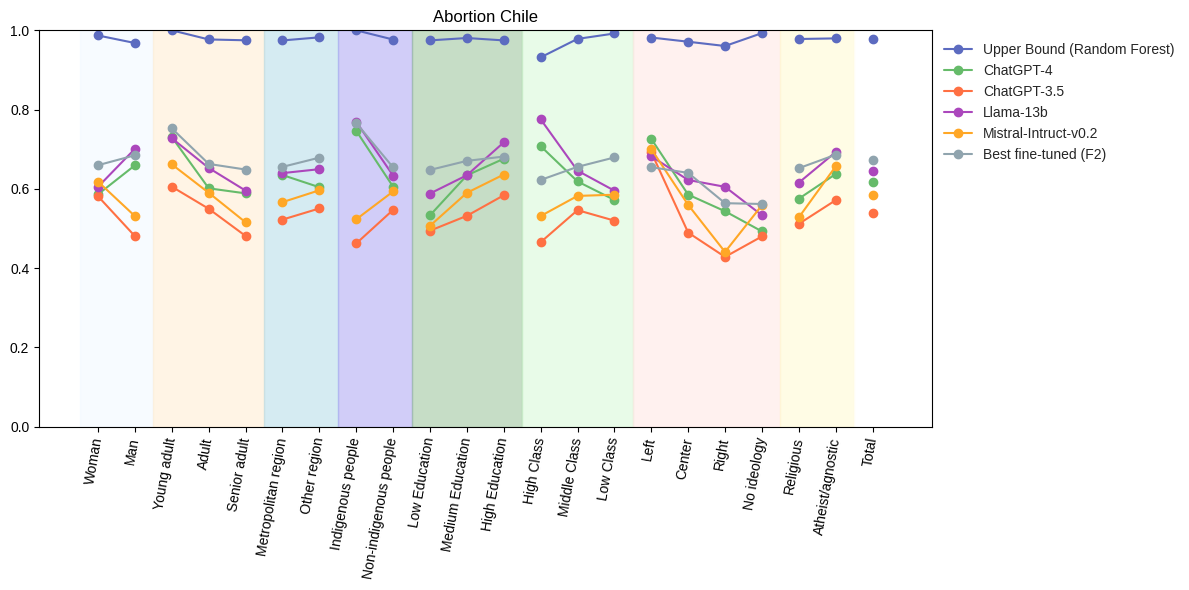

In [48]:
# Colors for each model
modelos_colores = {
    "Upper Bound (Random Forest)": "#5c6bc0",
    "ChatGPT-4": "#66bb6a",
    "ChatGPT-3.5": "#ff7043",
    "Llama-13b": "#ab47bc",
    "Mistral-Intruct-v0.2": "#ffa726",
    "T-zero": "#f48fb1",
    "Best fine-tuned (F2)": "#90a4ae",
    "Embedding + RandomForest": "#1e88e5"
}

modelos = [results_rf, gpt4_json_metrics, gpt3_json_metrics, llama_json_metrics, mistral_json_metrics, f_1_metrics]
modelos_nombres = ["Upper Bound (Random Forest)", "ChatGPT-4", "ChatGPT-3.5", "Llama-13b", "Mistral-Intruct-v0.2", "Best fine-tuned (F2)", "Embedding + RandomForest"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Abortion Chile")

## Performance comparison between prompt variation for each model

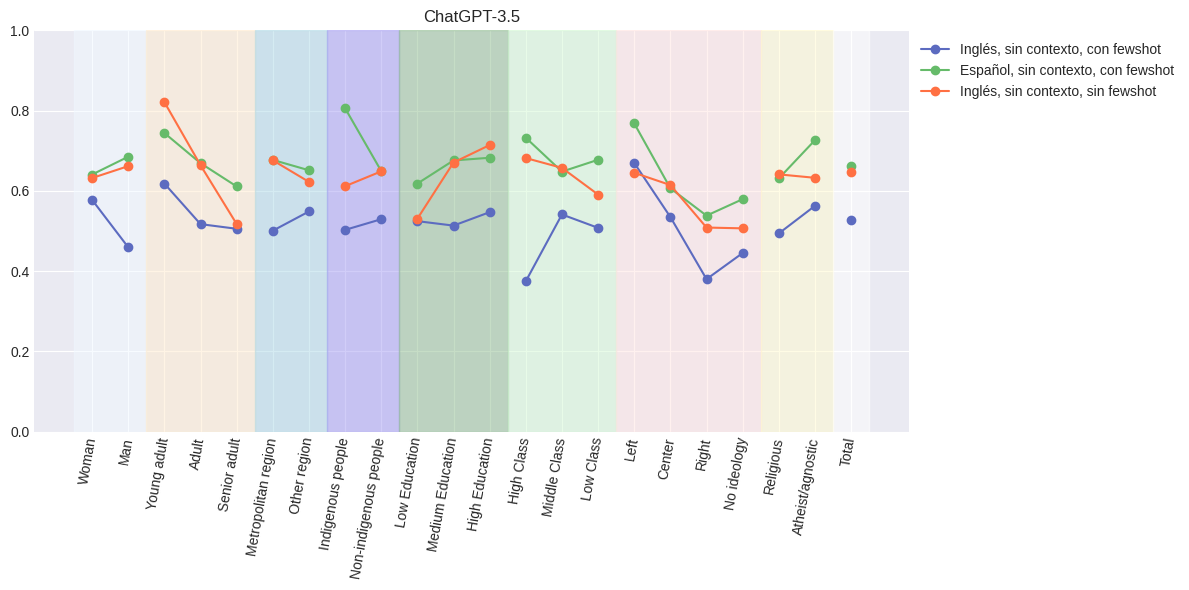

In [50]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",
    "Español, sin contexto, con fewshot": "#66bb6a",
    "Inglés, sin contexto, sin fewshot": "#ff7043",
    "Inglés, con contexto, con fewshot": "#ab47bc",
}

modelos = [gpt3_text_with_preamble_metrics, gpt3_esp_metrics, gpt_metrics_0]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "ChatGPT-3.5")

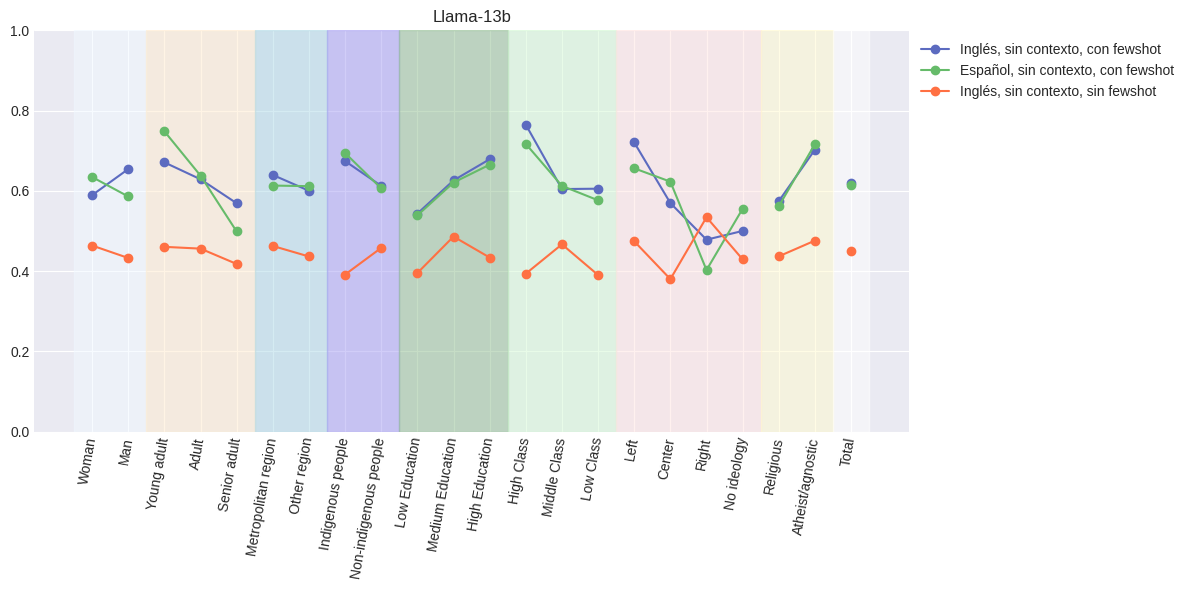

In [52]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",  # Azul suave
    "Español, sin contexto, con fewshot": "#66bb6a",               # Verde suave
    "Inglés, sin contexto, sin fewshot": "#ff7043", # Naranja suave
    "Inglés, con contexto, con fewshot": "#ab47bc",                 # Morado suave
}

modelos = [llama_text_with_preamble_metrics, llama_esp_metrics, llama_metrics_0]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Llama-13b")

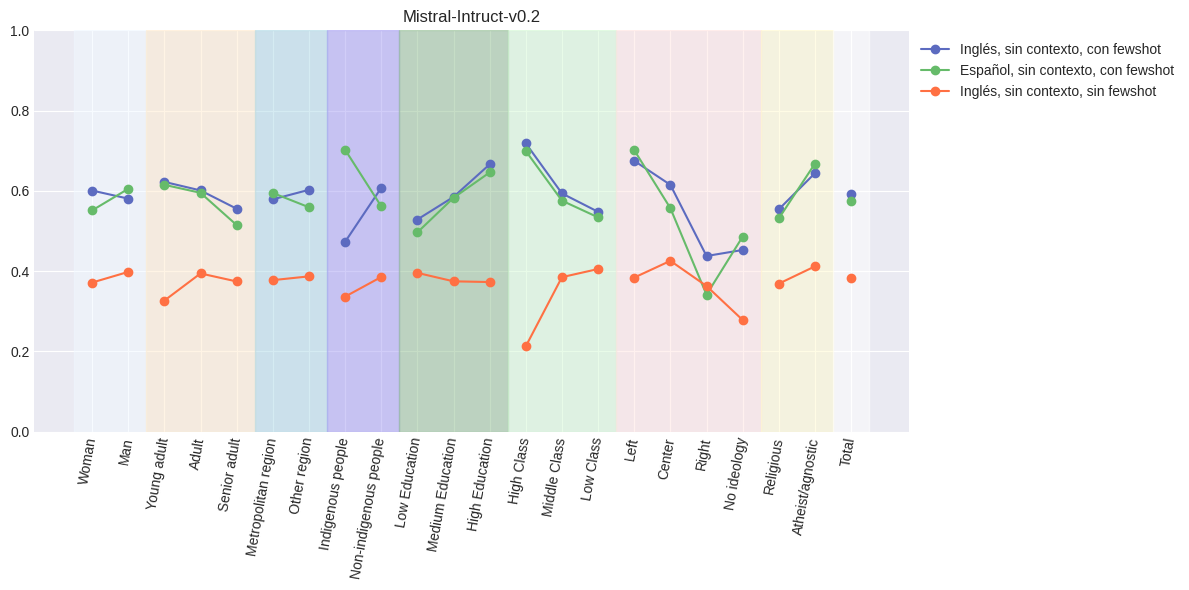

In [53]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",  # Azul suave
    "Español, sin contexto, con fewshot": "#66bb6a",               # Verde suave
    "Inglés, sin contexto, sin fewshot": "#ff7043", # Naranja suave
    "Inglés, con contexto, con fewshot": "#ab47bc",                 # Morado suave
}

modelos = [mistral_text_with_preamble_metrics, mistral_esp_metrics, mistral_metrics_0]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Mistral-Intruct-v0.2")

# Bar PLots

## Prompt Designs Comparison


### Metrics Tables

In [54]:
llama_table_p = metrics_by_prompt_table([llama_text_metrics, llama_list_metrics, llama_json_metrics, llama_text_with_preamble_metrics, llama_refpaper_metrics], "Llama-13b")
llama_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,Text,0.487879,0.923803,0.638535
1,Llama-13b,List,0.495455,0.910286,0.641662
2,Llama-13b,Chain of thought,0.516667,0.860982,0.645797
3,Llama-13b,Text with Preamble,0.498485,0.816357,0.618997
4,Llama-13b,Completion,0.487879,0.878042,0.627237


In [55]:
mistral_table_p = metrics_by_prompt_table([mistral_text_metrics, mistral_list_metrics, mistral_json_metrics, mistral_text_with_preamble_metrics, mistral_refpaper_metrics], "Mistral")
mistral_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral,Text,0.434848,0.714376,0.540617
1,Mistral,List,0.448485,0.703962,0.547906
2,Mistral,Chain of thought,0.450000,0.833751,0.584518
3,Mistral,Text with Preamble,0.460606,0.833269,0.593270
4,Mistral,Completion,0.507576,0.800314,0.621184


In [56]:
t0_table_p = metrics_by_prompt_table([t0_text_metrics, t0_list_metrics, t0_json_metrics, t0_text_with_preamble_metrics, t0_refpaper_metrics], "T-zero", names_list=["Text-template", "List-Template", "Estructura JSON", "Diseñado por autores", "Prompt del paper"])
t0_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,T-zero,Text-template,0.245455,0.412038,0.307643
1,T-zero,List-Template,0.163636,0.188133,0.175032
2,T-zero,Estructura JSON,0.242424,0.428586,0.309681
3,T-zero,Diseñado por autores,0.269697,0.441998,0.334990
4,T-zero,Prompt del paper,0.000000,0.006638,0.000000


In [57]:
chatgpt_table_p = metrics_by_prompt_table([gpt3_list_metrics, gpt3_text_metrics, gpt3_json_metrics, gpt3_text_with_preamble_metrics, gpt3_refpaper_metrics], "GPT3.5")
chatgpt_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT3.5,Text,0.439394,0.678016,0.533226
1,GPT3.5,List,0.451515,0.653668,0.534103
2,GPT3.5,Chain of thought,0.431818,0.717853,0.539253
3,GPT3.5,Text with Preamble,0.430303,0.684172,0.528323
4,GPT3.5,Completion,0.446970,0.678779,0.539008


### Plots

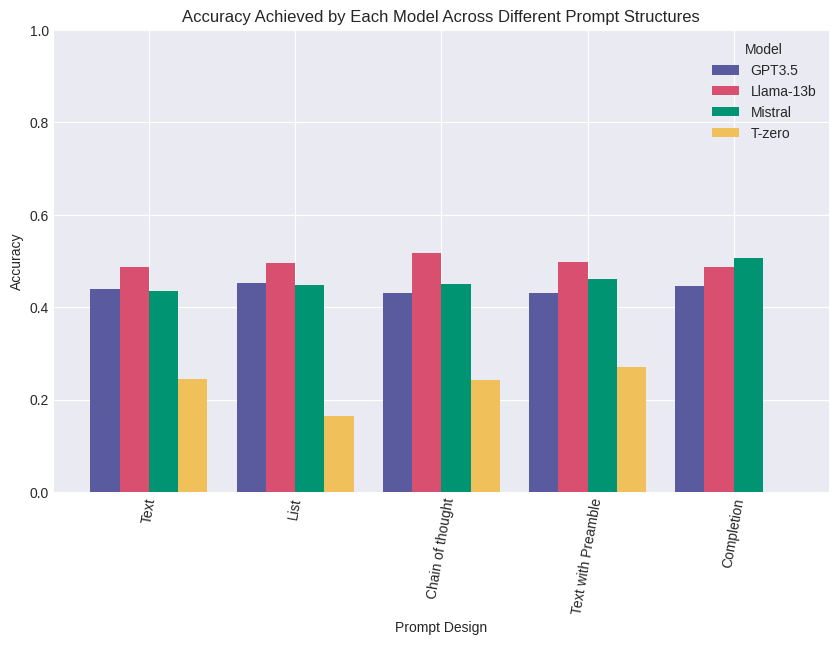

In [58]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p], "Accuracy Achieved by Each Model Across Different Prompt Structures",  "Prompt Design")

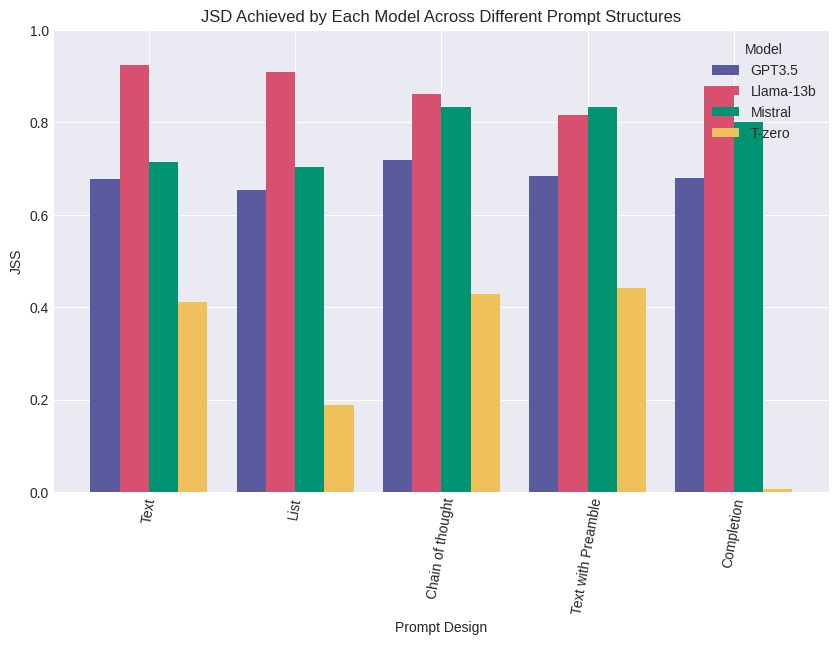

In [59]:
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p ], "JSD Achieved by Each Model Across Different Prompt Structures", "Prompt Design", metric="JSS")

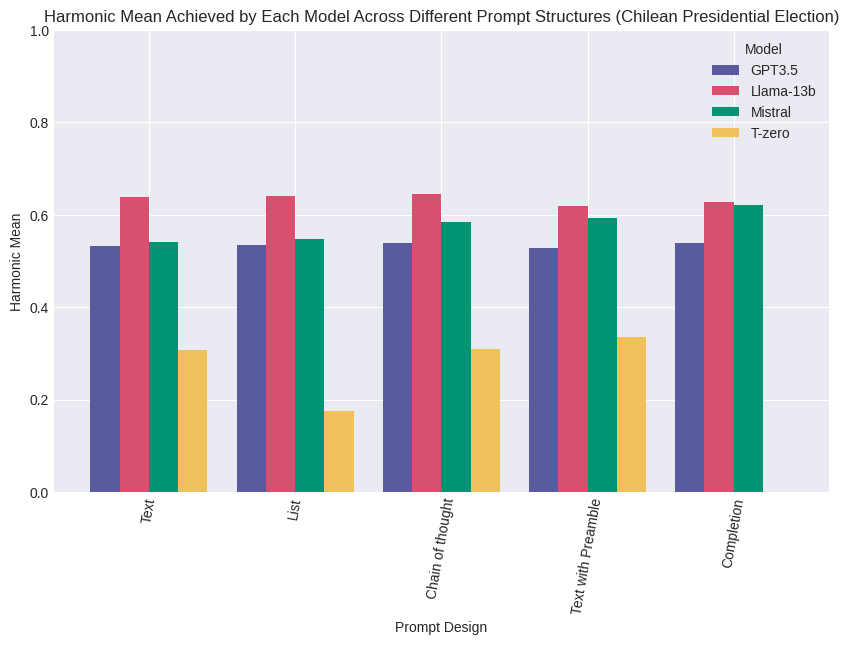

In [60]:
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p], "Harmonic Mean Achieved by Each Model Across Different Prompt Structures (Chilean Presidential Election)", "Prompt Design", metric="Harmonic Mean")

## Prompting Sin fewshot


### Metrics Tables

In [64]:
names_list=["English, without context, with fewshot", "Spanish, without context, with fewshot", "English, without context, without fewshot"]

In [65]:
gpt_0_table = metrics_by_prompt_table([gpt3_text_with_preamble_metrics, gpt3_esp_metrics, gpt_metrics_0], "GPT-3.5-turbo", names_list = names_list)
gpt_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT-3.5-turbo,"English, without context, with fewshot",0.430303,0.684172,0.528323
1,GPT-3.5-turbo,"Spanish, without context, with fewshot",0.543939,0.849116,0.663100
2,GPT-3.5-turbo,"English, without context, without fewshot",0.515152,0.865429,0.645854


In [66]:
llama_0_table = metrics_by_prompt_table([llama_text_with_preamble_metrics, llama_esp_metrics, llama_metrics_0], "Llama-13b", names_list=names_list)
llama_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,"English, without context, with fewshot",0.498485,0.816357,0.618997
1,Llama-13b,"Spanish, without context, with fewshot",0.480303,0.852416,0.614410
2,Llama-13b,"English, without context, without fewshot",0.337879,0.678399,0.451090


In [67]:
mistral_0_table = metrics_by_prompt_table([mistral_text_with_preamble_metrics, mistral_esp_metrics, mistral_metrics_0], "Mistral", names_list=names_list)
mistral_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral,"English, without context, with fewshot",0.460606,0.833269,0.593270
1,Mistral,"Spanish, without context, with fewshot",0.492424,0.689488,0.574527
2,Mistral,"English, without context, without fewshot",0.286364,0.579390,0.383287


### Plots

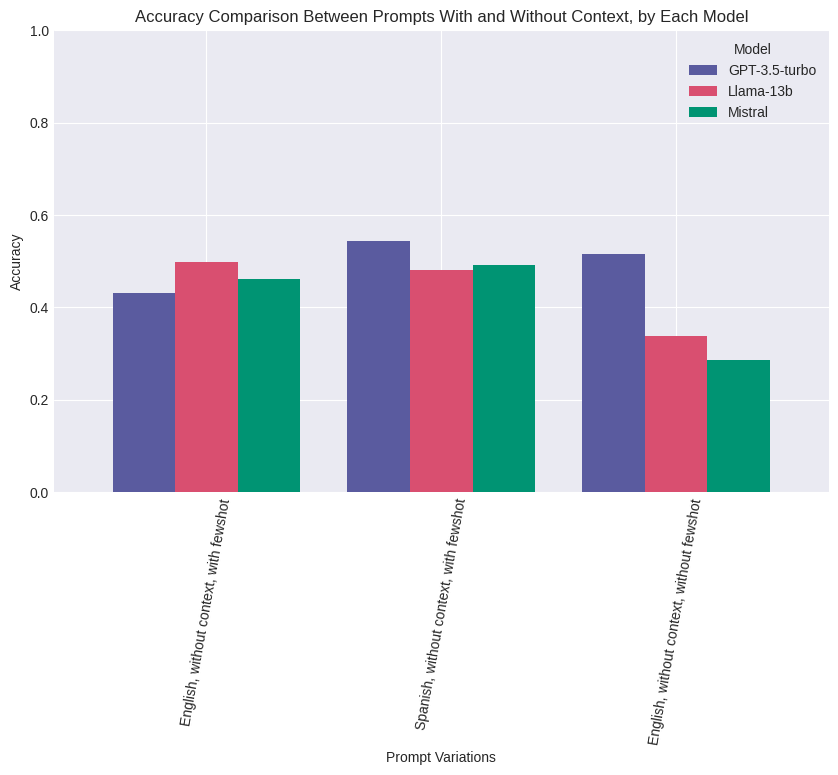

In [68]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "Accuracy Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "Accuracy")

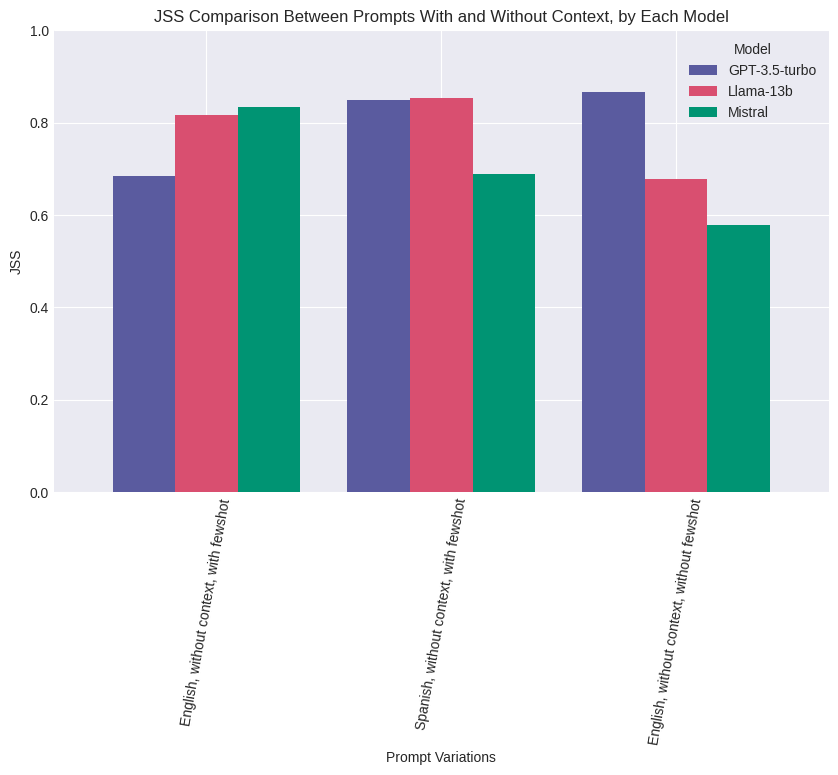

In [69]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "JSS Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "JSS")

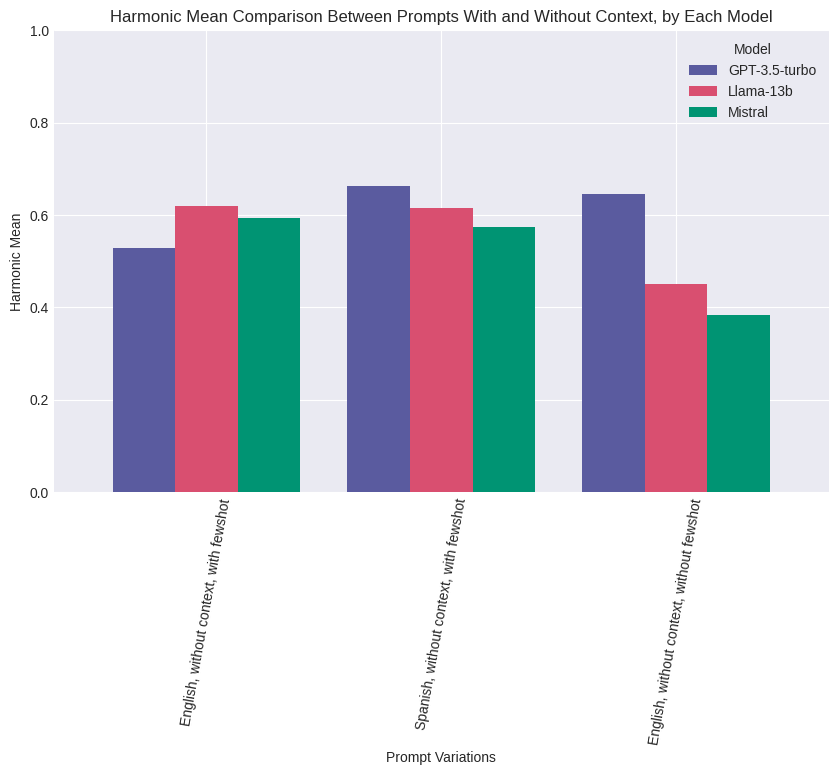

In [70]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "Harmonic Mean Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "Harmonic Mean")

## Votes Distribution per Sociodemographic Group

In [71]:
df = pd.read_csv(results_route +"exp_inputs_filtrado.csv")

In [72]:
quantities_per_option_per_group(df, column_to_predict, ["Prohibited", "Allowed in special cases", "Allowed"])

,Group,Prohibited,Allowed in special cases,Allowed
0,Woman,70,163,152
1,Man,38,149,88
2,Young adult,2,30,46
3,Adult,53,183,151
4,Senior adult,53,99,43
5,Metropolitan region,32,136,120
6,Other region,76,176,120
7,Indigenous people,3,32,23
8,Non-indigenous people,104,278,216
9,Low Education,62,100,43


In [74]:
quantities_per_option_per_group(llama_json, "pred", ["Prohibited", "Allowed in special cases", "Allowed"])

,Group,Prohibited,Allowed in special cases,Allowed
0,Woman,36,243,106
1,Man,31,175,69
2,Young adult,3,39,36
3,Adult,38,238,111
4,Senior adult,26,141,28
5,Metropolitan region,22,184,82
6,Other region,45,234,93
7,Indigenous people,4,31,23
8,Non-indigenous people,62,385,151
9,Low Education,31,140,34


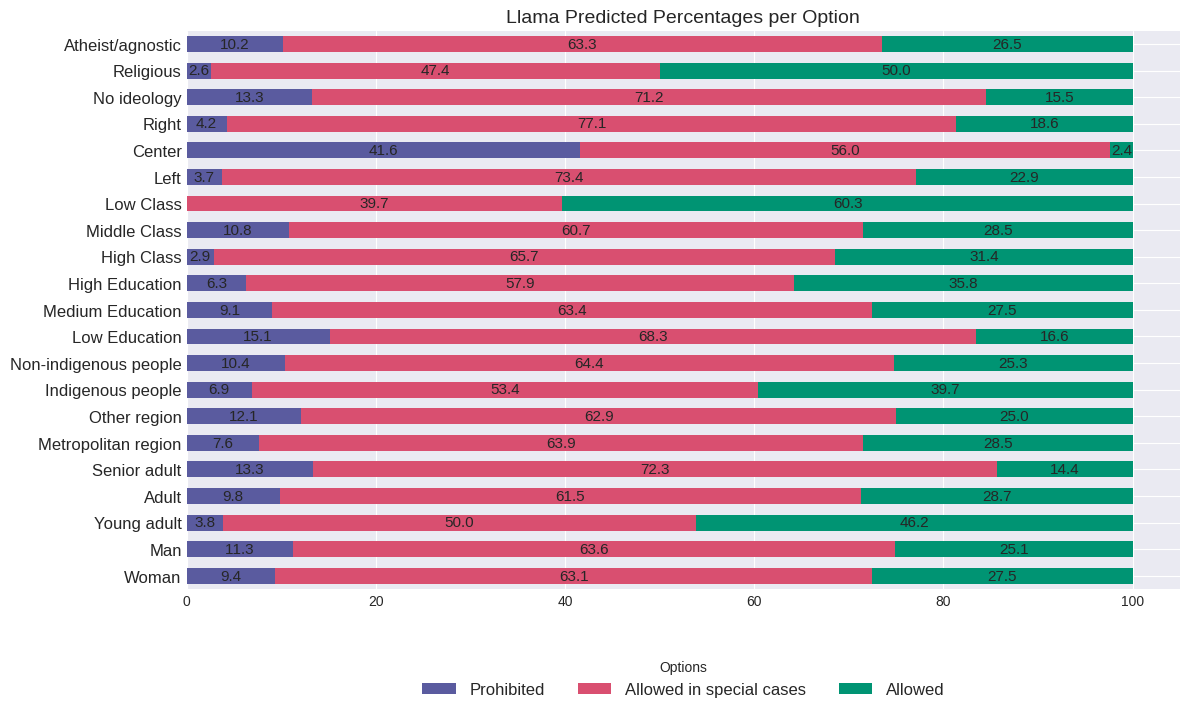

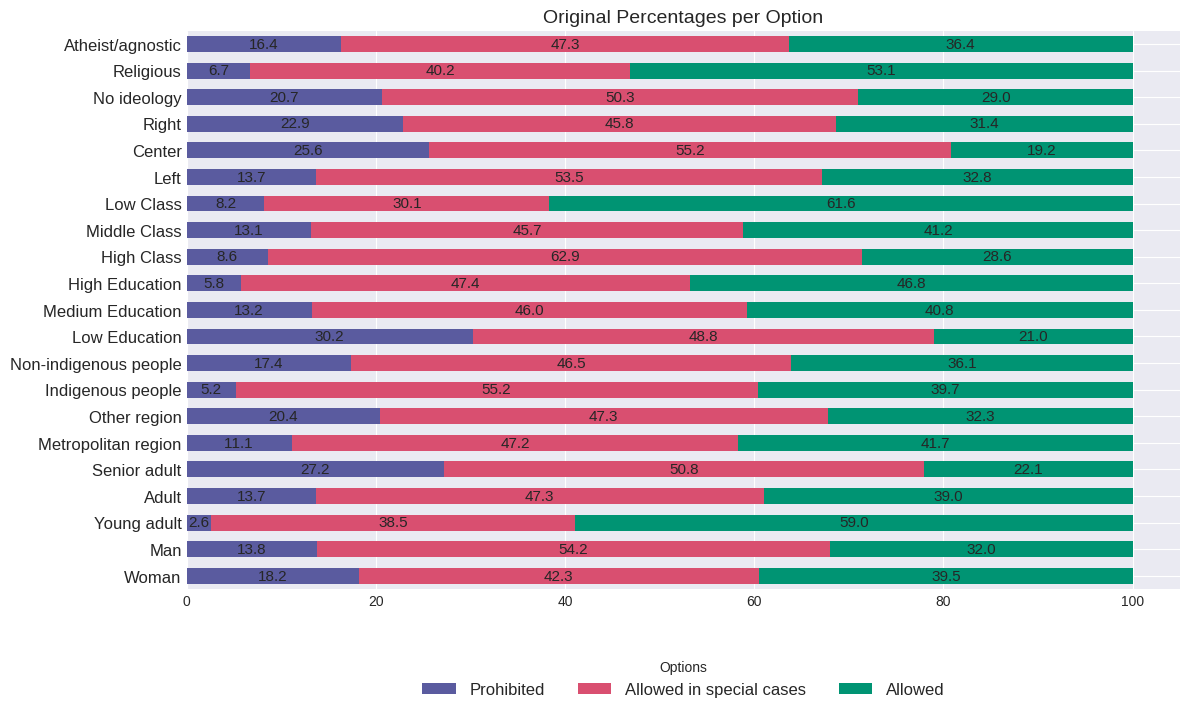

In [75]:
prop_llama = distribution_of_votes_per_group_graph(llama_json, "pred", ["Prohibited", "Allowed in special cases", "Allowed"], 'Llama Predicted Percentages per Option')
prop_original = distribution_of_votes_per_group_graph(df, column_to_predict, ["Prohibited", "Allowed in special cases", "Allowed"], 'Original Percentages per Option')



## Ablation Experiment
Results and graphs of ablation Experiment, using Llama-13b (the best model) and chain of thought prompt

In [77]:
llama_json_wpv = data_charger(results_route +"exp_inputs_filtrado.csv",  results_route +f"{experiment}_chile_llama_cot_without_political_vars.jsonl", d)
llama_json_onlypol = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_llama_cot_only_political_vars.jsonl", d)

In [79]:
df_llama13b_ablation = ablation_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot_ablation.jsonl", d, remove=None)
df_llama13b_ablation

ValueError: Length of values (555) does not match length of index (660)

In [ ]:
df_llama13b_ablation.rename(columns={'pred_indigenous': 'pred_race'}, inplace=True)

In [ ]:
df_list=[llama_json, llama_json_wpv, llama_json_onlypol]

Con llama13b se ve un comportamiento un poco más similar al de GPT, el rendimiento decae si no se incluyen las viariables políticas, o si solo se incluyen aquellas sin ninguna informacion sociodemográfica. Hay 2 variables: edad y escolaridad, que al quitarlas mejoran la precision pero nuevamente no logra superar el 5% por lo que no es un cambio considerable.

En este caso, no usar contexto hace empeorar la precisión en un 20%.

Nuevamente quitra la ideología genera una pérdida de precisión.

In [ ]:
ablation_graph(df_list,df_llama13b_ablation, column_to_predict, 'Llama Results for Ablation Experiment', 'Harmonic Mean')